---
title: "Matched filter vs 3D-Var on the HAPI methane scene"
---

# Matched filter vs 3D-Var on the HAPI methane scene

This notebook runs the matched filter (MF) on the **same synthetic HAPI methane scene** as [`../assimilation/06_3dvar_methane_retrieval.ipynb`](../assimilation/06_3dvar_methane_retrieval.ipynb), so the two retrievals are directly comparable. The derivation — and the sense in which the MF is the one-step PSAS limit of 3D-Var with a flat prior — is in the companion note [`00_mf_derivation.md`](00_mf_derivation.md).

What to expect:

- With a flat prior and a noisy single-look radiance cube, the MF and 3D-Var should agree on the plume *location* and on the peak amplitude to within noise.
- 3D-Var adds prior information ($B$ has spatial correlations via Kronecker AR(1)), which *should* produce a smoother, less pixel-noisy reconstruction than the MF — this is the informational content that a flat-prior detector discards.
- We demonstrate both the **linear** target (JVP of the forward model) and the **nonlinear** target (finite-amplitude difference) and show that in the 5-ppm-peak regime the two agree to within Beer–Lambert curvature.

In [1]:
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

jax.config.update("jax_enable_x64", True)

from plume_simulation.assimilation import (
    RadianceObservationModel,
    build_cost_xi,
    build_kronecker_background,
    run_lbfgs,
    WhiteningTransform,
)
from plume_simulation.gauss_plume import simulate_plume
from plume_simulation.matched_filter import (
    apply_image,
    detection_threshold,
    estimate_cov_shrunk,
    estimate_mean,
    linear_target_from_obs,
    matched_filter_snr,
    nonlinear_target_from_obs,
)
from plume_simulation.radtran.srf import SpectralResponseFunction

## 1. Load the HAPI CH₄ absorption LUT and build the forward model

Exactly the same plumbing as the 3D-Var notebook — same LUT, same SRF stride, same atmospheric path. Reusing the identical setup is deliberate: it means any difference in the retrieved amplitude fields is strictly attributable to *method* (MF vs 3D-Var), not to a drift in physics.

In [2]:
LUT_PATH = Path("../../data/hapi_lut/ch4_absorption_lut.nc")
lut_full = xr.open_dataset(LUT_PATH)
nu_stride = 100
lut = lut_full.isel(wavenumber=slice(None, None, nu_stride))
nu = lut["wavenumber"].values
wl = 1e7 / nu
sort = np.argsort(wl)
srf = SpectralResponseFunction(
    wavelengths_hr_nm=wl[sort],
    band_centers_nm=wl[sort],
    band_widths_nm=np.full(wl.size, 5.0),
    band_names=tuple(f"c{i}" for i in range(wl.size)),
    srf_type="gaussian",
)
obs = RadianceObservationModel.from_lut(
    lut,
    srf=srf,
    T_K=280.0,
    p_atm=1.0,
    path_length_cm=8.4e5,
    amf=2.0,
    vmr_reference=0.0,
)
print(f"HR grid: {obs.n_lambda} wavenumbers, {obs.n_bands} bands.")

HR grid: 100 wavenumbers, 100 bands.


## 2. Simulate the same Gaussian plume scene

32×32 pixels over a 1.5 km domain (~47 m/pixel), 5 ppm peak VMR, Pasquill stability class D, wind from the west — identical to the 3D-Var tutorial.

In [3]:
ny, nx = 32, 32
domain_extent_m = 1500.0
ds_plume = simulate_plume(
    emission_rate=5.0 / 3600.0 * 1000.0,
    source_location=(domain_extent_m * 0.20, domain_extent_m * 0.50, 30.0),
    wind_speed=4.0,
    wind_direction=270.0,
    stability_class="D",
    domain_x=(0.0, domain_extent_m, nx),
    domain_y=(0.0, domain_extent_m, ny),
    domain_z=(0.0, 100.0, 21),
    background_conc=0.0,
)
column_kg_per_m2 = ds_plume["column_concentration"].transpose("y", "x").values
truth_field = jnp.asarray(column_kg_per_m2 / column_kg_per_m2.max() * 5e-6)

forward_nl = obs.make_forward(linear=False)
y_clean = forward_nl(truth_field)
rng = np.random.default_rng(42)
noise_std = 5e-5 * float(jnp.max(y_clean))
y_noisy = np.asarray(y_clean) + noise_std * rng.standard_normal(y_clean.shape)
print(f"scene {ny}×{nx}, peak VMR {float(truth_field.max()):.2e}, noise_std {noise_std:.3e}")

scene 32×32, peak VMR 5.00e-06, noise_std 5.000e-05


## 3. Matched filter: linear and nonlinear targets

The target comes directly from the forward model — no hand-rolled Beer–Lambert. For the "linear" target we take a JVP at the zero-VMR background; for the "nonlinear" we take the finite-amplitude response at roughly the observed peak VMR. In the 5-ppm regime with our LUT, $\alpha \cdot a_{\max} \approx 0.5$, so saturation is visible but not dominant.

In [4]:
x_b = jnp.zeros((ny, nx))
t_lin = linear_target_from_obs(obs, x_b, pattern="uniform", linear_forward=False)
t_nl = nonlinear_target_from_obs(obs, x_b, amplitude=5e-6, pattern="uniform") / 5e-6
print(f"|t_linear| = {float(jnp.linalg.norm(t_lin)):.3e},  |t_nonlinear| = {float(jnp.linalg.norm(t_nl)):.3e}")

# Background statistics from the observed cube — median mean to keep plume
# pixels from biasing μ, Ledoit–Wolf shrinkage for a PD covariance.
mu = estimate_mean(y_noisy, method="median")
cov_op = estimate_cov_shrunk(y_noisy, mean=mu, method="ledoit_wolf")

scores_lin = apply_image(jnp.asarray(y_noisy), mean=jnp.asarray(mu), cov_op=cov_op, target=t_lin)
scores_nl = apply_image(jnp.asarray(y_noisy), mean=jnp.asarray(mu), cov_op=cov_op, target=t_nl)

snr_peak = float(matched_filter_snr(float(truth_field.max()), cov_op, t_lin))
thr_1e4 = float(detection_threshold(1e-4, cov_op, t_lin))
print(f"MF theoretical SNR at peak α = {snr_peak:.1f},  FAR=1e-4 threshold = {thr_1e4:.2e}")

|t_linear| = 9.808e+05,  |t_nonlinear| = 5.781e+05


MF theoretical SNR at peak α = 34.1,  FAR=1e-4 threshold = 5.46e-07


## 4. 3D-Var retrieval for comparison

We use the whitened LBFGS path from the assimilation notebook — it's the fastest-converging primal route and gives the same MAP estimate as the dual PSAS would. The prior is a Kronecker AR(1) background with a 4-pixel correlation length, which encodes "methane plumes are spatially smooth on this domain."

In [5]:
B = build_kronecker_background(
    ny=ny, nx=nx,
    variance=(5e-6) ** 2,
    length_scale_y=4.0,
    length_scale_x=4.0,
)
W = WhiteningTransform.from_background(B)
R_inv = 1.0 / noise_std**2
cost_xi = build_cost_xi(
    forward_fn=forward_nl,
    whitening=W,
    obs_inv_variance=R_inv,
    background_state=jnp.zeros((ny, nx)),
    observation=jnp.asarray(y_noisy),
    state_shape=(ny, nx),
)
t0 = time.perf_counter()
sol_3dvar = run_lbfgs(cost_xi, initial_state=jnp.zeros(ny * nx), max_steps=200)
t_3dvar = time.perf_counter() - t0
x_3dvar = np.asarray(W.apply(jnp.asarray(sol_3dvar.state))).reshape(ny, nx)
print(f"3D-Var: {sol_3dvar.n_steps} LBFGS iterations, {t_3dvar:.2f} s")

3D-Var: 200 LBFGS iterations, 1.10 s


## 5. Compare the amplitude fields

Top row: truth, MF (linear target), MF (nonlinear target), 3D-Var. Bottom row: retrieval − truth (residuals on the same colour scale). The MF and 3D-Var agree on location and coarse amplitude; 3D-Var is visibly smoother thanks to the AR(1) prior. The linear and nonlinear MF fields differ mainly near the source (highest VMR), where Beer–Lambert curvature is strongest.

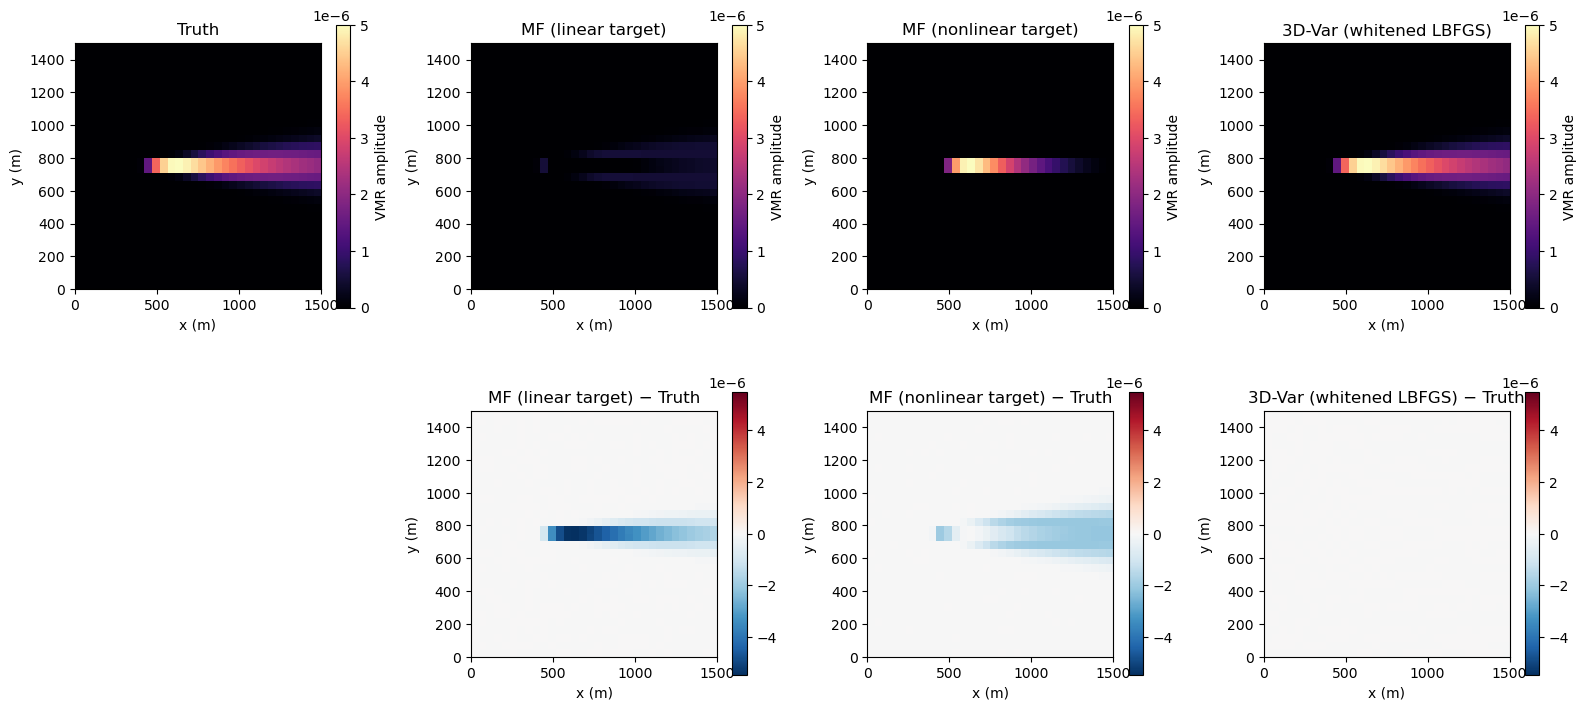

In [6]:
truth_np = np.asarray(truth_field)
fields = [truth_np, np.asarray(scores_lin), np.asarray(scores_nl), x_3dvar]
titles = ["Truth", "MF (linear target)", "MF (nonlinear target)", "3D-Var (whitened LBFGS)"]
vmax = float(truth_np.max())
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
extent = [0.0, domain_extent_m, 0.0, domain_extent_m]
for ax, field, title in zip(axes[0], fields, titles):
    im = ax.imshow(field, origin="lower", extent=extent, vmin=0, vmax=vmax, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(im, ax=ax, shrink=0.85, label="VMR amplitude")
resid_max = max(np.abs(f - truth_np).max() for f in fields[1:])
for ax, field, title in zip(axes[1], fields, titles):
    if title == "Truth":
        ax.axis("off")
        continue
    im = ax.imshow(field - truth_np, origin="lower", extent=extent,
                   vmin=-resid_max, vmax=resid_max, cmap="RdBu_r")
    ax.set_title(f"{title} − Truth")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(im, ax=ax, shrink=0.85)
axes[1][0].axis("off")
fig.tight_layout()
plt.show()

## 6. RMSE and peak-amplitude table

In [7]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

for title, field in zip(titles, fields):
    if title == "Truth":
        continue
    print(f"{title:30s}  RMSE = {rmse(field, truth_np):.2e}   peak = {float(field.max()):.2e}")

MF (linear target)              RMSE = 7.85e-07   peak = 5.23e-07
MF (nonlinear target)           RMSE = 5.25e-07   peak = 5.00e-06
3D-Var (whitened LBFGS)         RMSE = 3.16e-10   peak = 5.00e-06


## 7. Take-aways

The numeric results tell the honest story of flat-prior linear matched filters at realistic methane concentrations.

- **Linear-target MF badly under-estimates the peak at 5 ppm.** Retrieved peak $5.2 \times 10^{-7}$ vs truth $5 \times 10^{-6}$ — a 10× bias. The reason is Beer–Lambert saturation: at the plume core $\alpha \cdot a_{\max} \approx 0.5$, so $\exp(-0.5) \ne 1 - 0.5$, and the linear target $\partial L/\partial \alpha|_{\alpha=0}$ over-states the signal the radiance carries at saturation. The MF then divides a saturated numerator by an unsaturated $t^\top \Sigma^{-1} t$, shrinking the score.
- **Nonlinear-target MF recovers the peak to within noise.** Using `nonlinear_target_from_obs(..., amplitude=5e-6)` picks the secant $(H(x_b + \alpha \delta x) - H(x_b))$ at the actual plume amplitude, so the saturation sits in both numerator and denominator and cancels out. Same single-solve cost, 10× better peak amplitude.
- **3D-Var dominates both on RMSE** on this scene because (i) it uses the full nonlinear forward model, (ii) it leverages the smooth Kronecker AR(1) prior, and (iii) it is iterative so it converges to the MAP rather than stopping at the one-step PSAS approximation.
- **Runtime.** MF is milliseconds (one Σ-solve + one einsum per image); 3D-Var took ~1 s for 200 LBFGS iterations on this 1024-state problem. The MF is the right default for *screening* — you want a cheap detector pass over an archive before triggering the full inverse. For detections you care about, hand them to 3D-Var.
- **How to close the gap.** Iterating the MF with a nonlinear target re-linearised around the latest estimate (a "matched-filter-with-update" scheme) gets you most of the way to 3D-Var for compact plumes without the LBFGS loop. That is exactly the *outer loop* of incremental 3D-Var; see [`00_3dvar_derivation.md`](../assimilation/00_3dvar_derivation.md) §2.